In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hotel_bookings_data.csv')
df.shape

(119390, 29)

In [2]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,...,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,...,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,...,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,...,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,...,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df['children'] = df['children'].fillna(0)

In [5]:
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [6]:
df['city'] = df['city'].fillna('Unknown')

In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

33261


In [9]:
df = df.drop_duplicates()
df.shape

(86129, 29)

In [10]:
df['meal'].value_counts()

meal
Breakfast     67088
No Meal        9442
Dinner         8798
Undefined       454
Full Board      347
Name: count, dtype: int64

In [11]:
df['meal'] = df['meal'].replace('Undefined', 'No Meal')
df['meal'].value_counts()

meal
Breakfast     67088
No Meal        9896
Dinner         8798
Full Board      347
Name: count, dtype: int64

In [12]:
df['adr'].describe()

count    86129.000000
mean       106.634109
std         55.175319
min         -6.380000
25%         72.250000
50%         98.750000
75%        134.510000
max       5400.000000
Name: adr, dtype: float64

In [13]:
zero_guests = df[(df['adults'] + df['children'] + df['babies']) == 0]
zero_guests.shape[0]

165

In [14]:
# Check kitni rows adr > 1000 wali hain (extreme outliers)
print(df[df['adr'] > 1000].shape[0])

# Negative adr rows
print(df[df['adr'] < 0].shape[0])

1
1


In [15]:
# Remove negative adr
df = df[df['adr'] >= 0]

# Remove extreme outlier adr (>1000)
df = df[df['adr'] <= 1000]

# Remove zero-guest bookings
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

df.shape

(85962, 29)

In [16]:
df['hotel'].value_counts()

hotel
City Hotel      52421
Resort Hotel    33541
Name: count, dtype: int64

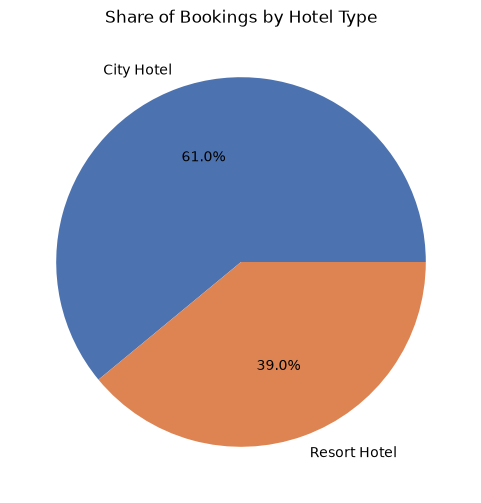

In [17]:
plt.figure(figsize=(6,6))
df['hotel'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0','#DD8452'])
plt.title('Share of Bookings by Hotel Type')
plt.ylabel('')
plt.show()

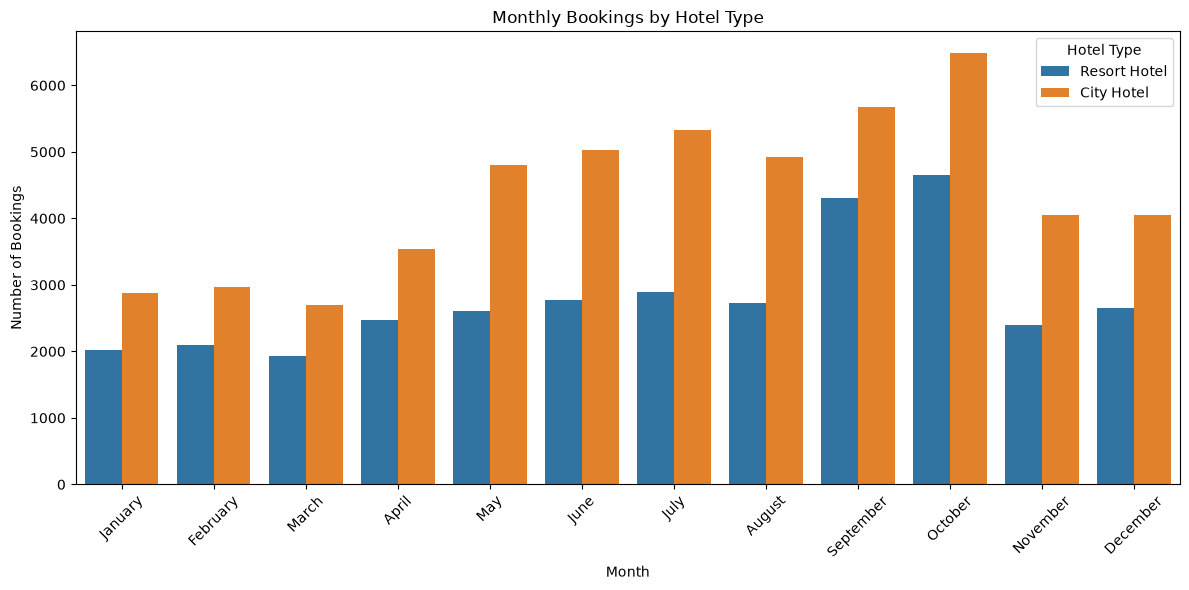

In [18]:
month_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='arrival_date_month', hue='hotel', order=month_order)
plt.title('Monthly Bookings by Hotel Type')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

### Observation: Seasonal Pattern

Bookings are highest between August and October, especially for City Hotel, 
which peaks around October. This is likely because this period includes 
late-summer holidays and the start of the autumn travel/conference season, 
when both leisure travelers and business travelers are more active. City 
Hotel's sharper rise suggests a stronger business/corporate travel influence 
during these months.

Bookings are lowest from January to March, which is typical of the off-season 
winter period when both leisure and business travel demand drop.

**Business decisions this trend could inform:** hotels could increase prices 
or offer premium packages during peak months (Aug–Oct), while running 
discounts, off-season promotions, or loyalty offers during the January–March 
lull to boost occupancy.

hotel
City Hotel      30.214990
Resort Hotel    23.493635
Name: is_canceled, dtype: float64


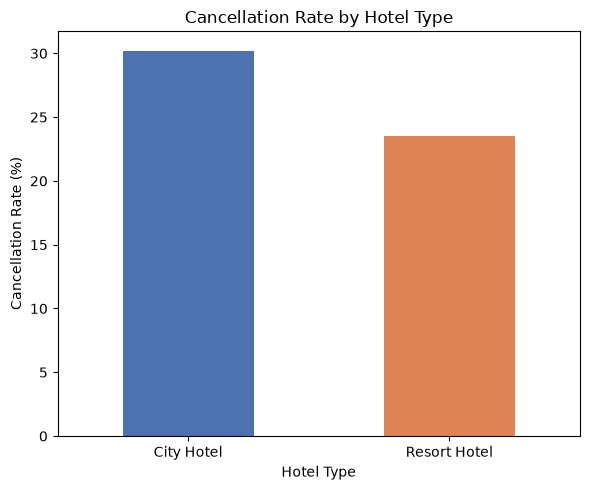

In [19]:
cancel_rate = df.groupby('hotel')['is_canceled'].mean() * 100
print(cancel_rate)

plt.figure(figsize=(6,5))
cancel_rate.plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_weekdays_nights']
df['total_nights'].describe()

count    85962.000000
mean         3.640760
std          2.749453
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_nights, dtype: float64

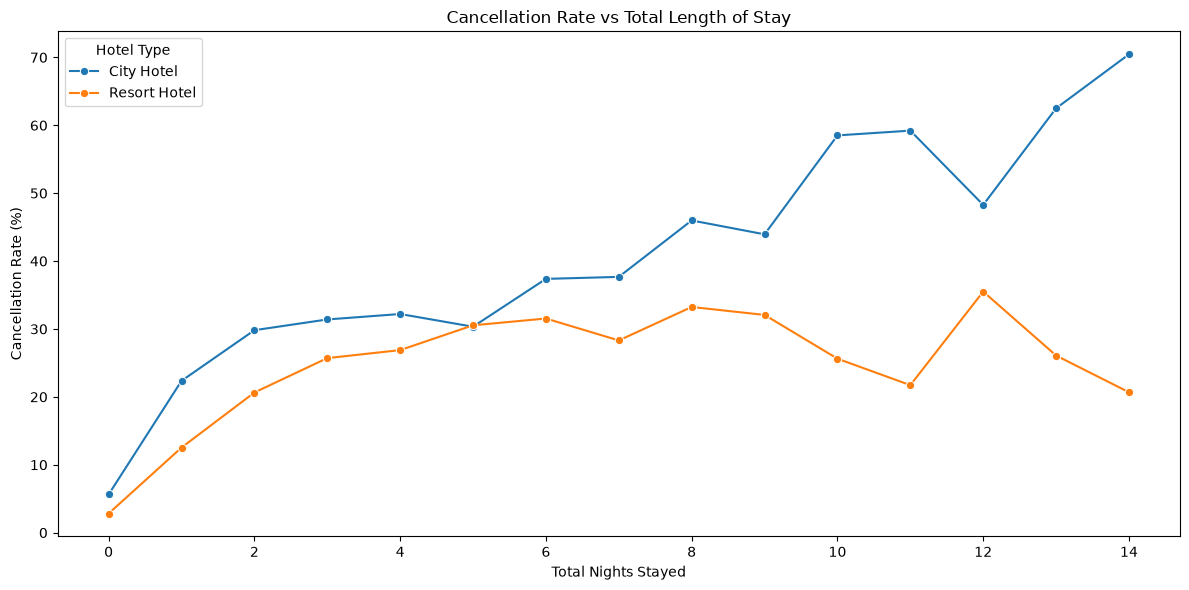

In [21]:
stay_df = df[df['total_nights'] <= 14]

cancel_by_stay = stay_df.groupby(['total_nights', 'hotel'])['is_canceled'].mean().reset_index()
cancel_by_stay['is_canceled'] = cancel_by_stay['is_canceled'] * 100

plt.figure(figsize=(12,6))
sns.lineplot(data=cancel_by_stay, x='total_nights', y='is_canceled', hue='hotel', marker='o')
plt.title('Cancellation Rate vs Total Length of Stay')
plt.xlabel('Total Nights Stayed')
plt.ylabel('Cancellation Rate (%)')
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

### Observation: Stay Duration vs Cancellation

The relationship between stay duration and cancellation rate is **positive for 
City Hotel** — cancellation rate rises sharply as the length of stay increases, 
from around 6% for 0-night stays to over 70% for 14-night stays. In contrast, 
**Resort Hotel shows a much flatter trend**, staying roughly between 20-35% 
regardless of stay duration.

**Possible reasons longer stays are cancelled more often (especially in City Hotel):**
1. Longer bookings are often made further in advance for business trips or 
   conferences, which are more likely to be rescheduled or cancelled due to 
   changing plans.
2. Guests booking long city stays may be more price-sensitive and cancel if 
   they find a better deal, whereas resort stays are often vacation-planned 
   and more firmly committed.

In [22]:
df['lead_time'].describe()

count    85962.000000
mean        79.324050
std         85.504682
min          0.000000
25%         11.000000
50%         49.000000
75%        124.000000
max        737.000000
Name: lead_time, dtype: float64

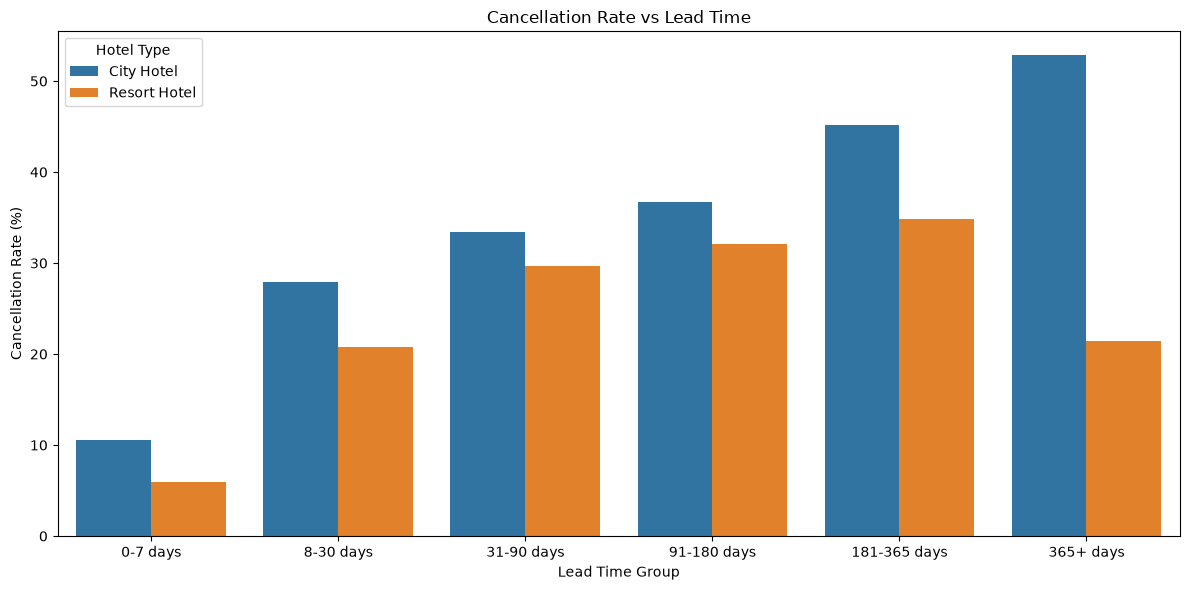

In [23]:
bins = [0, 7, 30, 90, 180, 365, 800]
labels = ['0-7 days', '8-30 days', '31-90 days', '91-180 days', '181-365 days', '365+ days']

df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels, include_lowest=True)

cancel_by_lead = df.groupby(['lead_time_group', 'hotel'])['is_canceled'].mean().reset_index()
cancel_by_lead['is_canceled'] = cancel_by_lead['is_canceled'] * 100

plt.figure(figsize=(12,6))
sns.barplot(data=cancel_by_lead, x='lead_time_group', y='is_canceled', hue='hotel')
plt.title('Cancellation Rate vs Lead Time')
plt.xlabel('Lead Time Group')
plt.ylabel('Cancellation Rate (%)')
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

### Observation: Lead Time vs Cancellation

Cancellation rate is lowest for bookings made 0-7 days before arrival 
(City Hotel ~10.5%, Resort Hotel ~6%), meaning last-minute bookings are 
rarely cancelled. Cancellation rate is highest for City Hotel bookings 
made 365+ days in advance (~53%), rising steadily and consistently as 
lead time increases.

Resort Hotel behaves differently: its cancellation rate rises up to the 
181-365 day range (~35%) but then **drops back down** for bookings made 
365+ days ahead (~21%). This suggests City Hotel bookings made far in 
advance (likely business trips or flexible plans) are cancelled far more 
often, while Resort Hotel guests who commit a year ahead may be genuinely 
locked into vacation plans and less likely to cancel.

## Stage 3: Summary and Recommendations

### Key Findings
- City Hotel is booked more often (61% of bookings vs 39% for Resort Hotel), 
  and bookings peak between August-October, likely due to holiday season 
  and business travel.
- Longer stays are strongly linked to higher cancellations in City Hotel 
  (rising from ~6% to ~70%), while Resort Hotel cancellations stay flatter 
  regardless of stay length.
- Cancellation rate rises sharply with lead time for City Hotel (up to ~53% 
  for 365+ day bookings), while Resort Hotel cancellations peak around 
  181-365 days and then decline for very long lead times.

### Recommendation 1 (Hotel type & seasonality)
Since Resort Hotel is booked less often, the business could run targeted 
marketing or bundled packages (e.g. resort + spa deals) to grow its share. 
For peak months (Aug-Oct), the hotel could introduce dynamic/premium pricing 
to maximize revenue, and offer discounts or loyalty perks in the low season 
(Jan-Mar) to boost occupancy.

### Recommendation 2 (Stay duration & cancellations)
Since long stays in City Hotel have very high cancellation rates, the hotel 
could apply stricter cancellation policies (e.g. non-refundable rates or 
partial deposits) for bookings longer than 7 nights, while keeping flexible 
policies for short stays where cancellation risk is low.

### Recommendation 3 (Lead time & cancellations)
Since cancellation risk rises steeply with lead time (especially for City 
Hotel bookings made far in advance), the hotel could require a deposit or 
partial prepayment for bookings made more than 90 days ahead, and send 
automated reminder/confirmation emails as the arrival date approaches to 
reduce no-shows and last-minute cancellations.

### Biggest Impact Recommendation
The lead-time-based deposit policy (Recommendation 3) is likely to have the 
biggest impact, since lead time shows the clearest and most consistent 
relationship with cancellation across the dataset — bookings made far in 
advance are cancelled far more often, and a deposit requirement directly 
targets this risk before it happens.